## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../../../Modules")

from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Peloponnese'
NUTS2_ID = 'EL65'

In [5]:
greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU Shapefiles/Greece/data/EL_Whole.shp",  encoding=enc)

In [6]:
greece_nuts3_gdf.head(5)

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [7]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [8]:
greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

In [9]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: EPSG:4326


In [10]:
greece_nuts3_gdf.head(5)

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [11]:
print(f'Length of greece_nuts3_gdf: {len(greece_nuts3_gdf)}')

Length of greece_nuts3_gdf: 52


In [12]:
#choose the correct region

nuts2_gdf = greece_nuts3_gdf.loc[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}'].copy()
nuts2_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
49,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL65,Peloponnisos,Πελοπόννησος,EL651,"Argolida, Arkadia","Αργολίδα, Αρκαδία",3.0,3,1,"MULTIPOLYGON (((22.26431 37.83916, 22.27648 37..."
50,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL65,Peloponnisos,Πελοπόννησος,EL652,Korinthia,Κορινθία,2.0,2,1,"MULTIPOLYGON (((23.11753 38.06065, 23.11906 38..."
51,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL65,Peloponnisos,Πελοπόννησος,EL653,"Lakonia, Messinia","Λακωνία, Μεσσηνία",2.0,3,1,"MULTIPOLYGON (((22.98080 37.04790, 22.99124 37..."


In [13]:
print(f'nuts2_gdf CRS: {nuts2_gdf.crs}')

nuts2_gdf CRS: EPSG:4326


<Axes: >

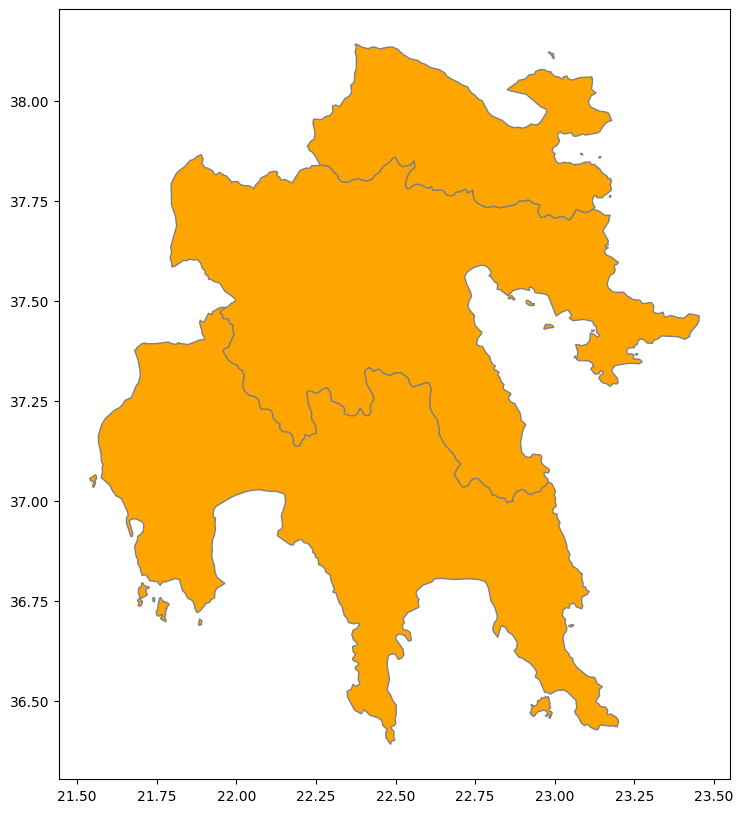

In [14]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [15]:
nuts2_gdf.NUTS3_NAME.unique()

array(['Αργολίδα, Αρκαδία', 'Κορινθία', 'Λακωνία, Μεσσηνία'], dtype=object)

In [16]:
nuts2_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_LATN','NUTS3_LATN',
                        'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace = True)
nuts2_gdf.reset_index(drop = True, inplace = True)
process_greek(nuts2_gdf, 'NUTS3_NAME')
process_greek(nuts2_gdf, 'NUTS2_NAME')

In [17]:
nuts2_gdf.head(5)

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,geometry
0,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια","MULTIPOLYGON (((22.26431 37.83916, 22.27648 37..."
1,EL65,πελοποννησος,EL652,κορινθια,"MULTIPOLYGON (((23.11753 38.06065, 23.11906 38..."
2,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια","MULTIPOLYGON (((22.98080 37.04790, 22.99124 37..."


<Axes: >

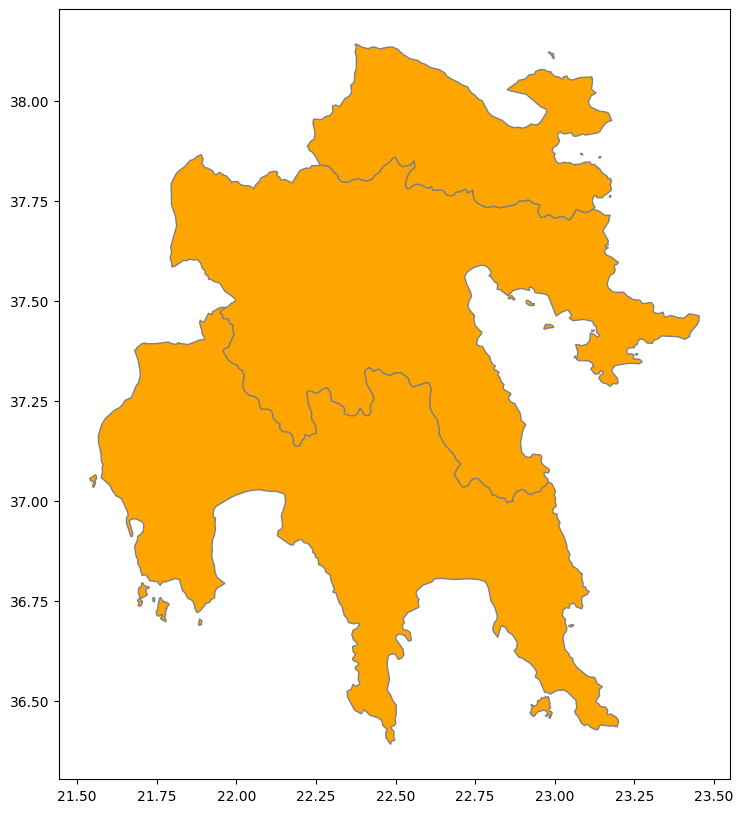

In [18]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [19]:
nuts3_units = nuts2_gdf['NUTS3_NAME'].unique().tolist()

if not os.path.exists(f'../../data/{NUTS2}/'):
    os.makedirs(f'../../data/{NUTS2}/')

with open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_SHP_NUTS3_Units_Processed.txt', 'w', encoding=enc) as f:
    for item in nuts3_units:
        f.write("%s\n" % item)

print(f"Number of NUTS3 Units in {NUTS2} (from shapefile): {len(nuts3_units)}")

Number of NUTS3 Units in Peloponnese (from shapefile): 3


In [20]:
nuts2_gdf.reset_index(inplace=True, drop = True)

In [29]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal='NUTS3_NAME', dimension=4)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [30]:
df_grid.head()

,geometry,centers,NAME,x,y
0,"POLYGON ((21.88190 37.60656, 21.88190 37.64250...",POINT (21.859408386564855 37.62453120600752),"αργολιδα, αρκαδια",21.85941,37.62453
1,"POLYGON ((21.88190 37.64250, 21.88190 37.67843...",POINT (21.859408386564855 37.66046458920795),"αργολιδα, αρκαδια",21.85941,37.66046
2,"POLYGON ((21.88190 37.67843, 21.88190 37.71436...",POINT (21.859408386564855 37.69639797240838),"αργολιδα, αρκαδια",21.85941,37.69640
3,"POLYGON ((21.88190 37.71436, 21.88190 37.75030...",POINT (21.859408386564855 37.73233135560881),"αργολιδα, αρκαδια",21.85941,37.73233
4,"POLYGON ((21.88190 37.75030, 21.88190 37.78623...",POINT (21.859408386564855 37.768264738809236),"αργολιδα, αρκαδια",21.85941,37.76826


In [31]:
df_grid.rename(columns={"NAME": "NUTS3_NAME"}, inplace = True)

<Axes: >

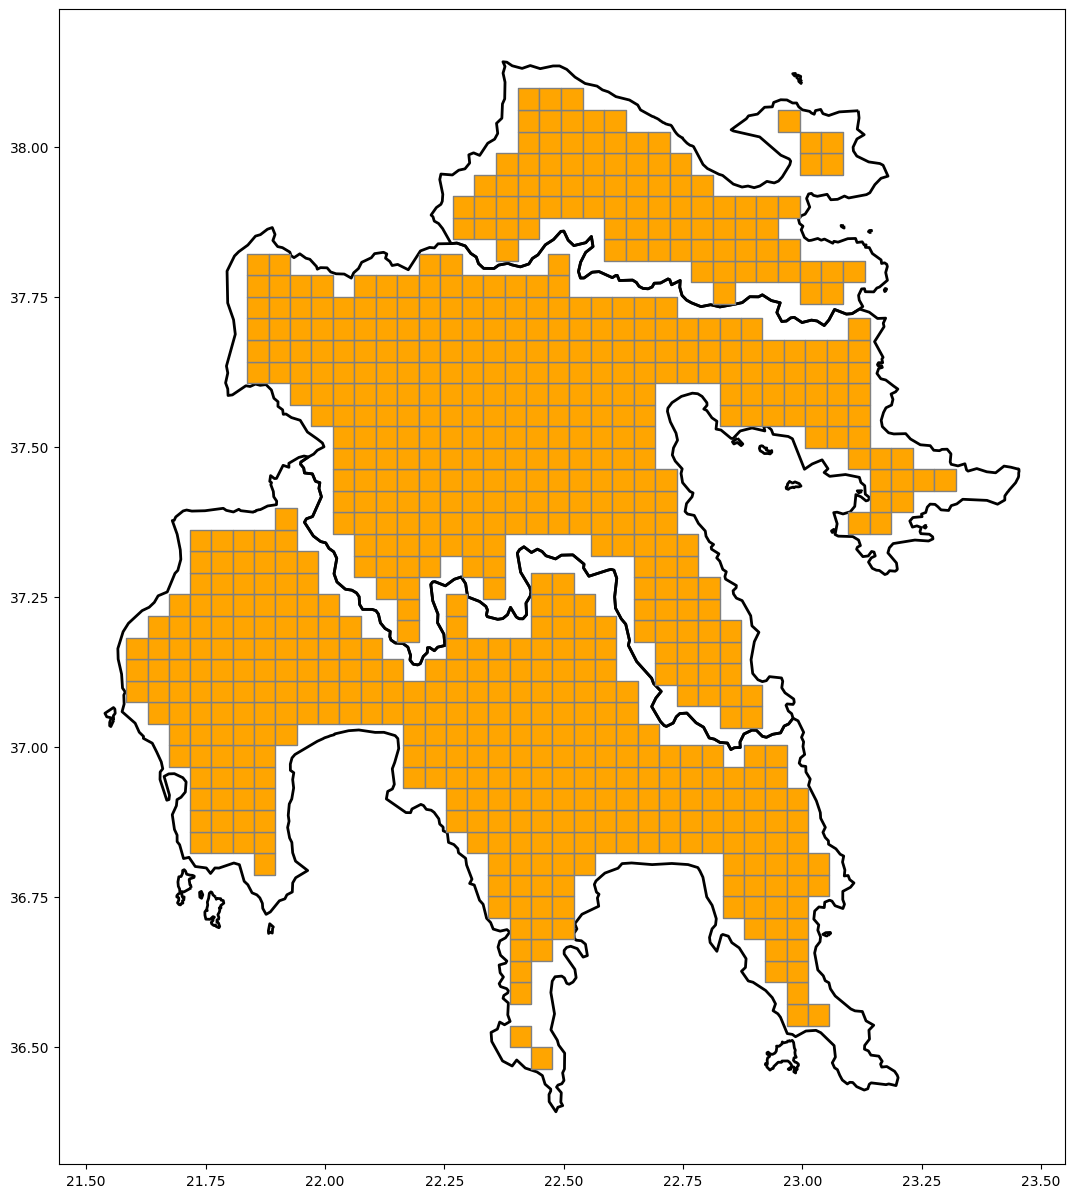

In [32]:
ax = nuts2_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [33]:
grid_nuts3 = df_grid['NUTS3_NAME'].unique().tolist()
print(f"Number of NUTS3 Units in Grid: {len(grid_nuts3)}")

Number of NUTS3 Units in Grid: 3


In [34]:
if (len(nuts3_units) != len(grid_nuts3)):
    delta = [item for item in nuts3_units if item not in grid_nuts3]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['NUTS3_NAME'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['NUTS3_NAME'] = lost_lau1['NUTS3_NAME']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [35]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [36]:
nuts2_grid

,geometry,NUTS3_NAME,x,y
0,"POLYGON ((21.88190 37.60656, 21.88190 37.64250...","αργολιδα, αρκαδια",21.85941,37.62453
1,"POLYGON ((21.88190 37.64250, 21.88190 37.67843...","αργολιδα, αρκαδια",21.85941,37.66046
2,"POLYGON ((21.88190 37.67843, 21.88190 37.71436...","αργολιδα, αρκαδια",21.85941,37.69640
3,"POLYGON ((21.88190 37.71436, 21.88190 37.75030...","αργολιδα, αρκαδια",21.85941,37.73233
4,"POLYGON ((21.88190 37.75030, 21.88190 37.78623...","αργολιδα, αρκαδια",21.85941,37.76826
...,...,...,...,...
705,"POLYGON ((23.01223 36.85901, 23.01223 36.89495...","λακωνια, μεσσηνια",22.98991,36.87698
706,"POLYGON ((23.01223 36.89495, 23.01223 36.93088...","λακωνια, μεσσηνια",22.98991,36.91292
707,"POLYGON ((23.05686 36.53561, 23.05686 36.57155...","λακωνια, μεσσηνια",23.03455,36.55358
708,"POLYGON ((23.05686 36.75121, 23.05686 36.78715...","λακωνια, μεσσηνια",23.03455,36.76918


In [37]:
if (len(nuts3_units) != len(grid_nuts3)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [38]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [39]:
nuts2_grid

,shape,NUTS3_NAME,x,y
0,"POLYGON ((21.88190 37.60656, 21.88190 37.64250...","αργολιδα, αρκαδια",21.85941,37.62453
1,"POLYGON ((21.88190 37.64250, 21.88190 37.67843...","αργολιδα, αρκαδια",21.85941,37.66046
2,"POLYGON ((21.88190 37.67843, 21.88190 37.71436...","αργολιδα, αρκαδια",21.85941,37.69640
3,"POLYGON ((21.88190 37.71436, 21.88190 37.75030...","αργολιδα, αρκαδια",21.85941,37.73233
4,"POLYGON ((21.88190 37.75030, 21.88190 37.78623...","αργολιδα, αρκαδια",21.85941,37.76826
...,...,...,...,...
705,"POLYGON ((23.01223 36.85901, 23.01223 36.89495...","λακωνια, μεσσηνια",22.98991,36.87698
706,"POLYGON ((23.01223 36.89495, 23.01223 36.93088...","λακωνια, μεσσηνια",22.98991,36.91292
707,"POLYGON ((23.05686 36.53561, 23.05686 36.57155...","λακωνια, μεσσηνια",23.03455,36.55358
708,"POLYGON ((23.05686 36.75121, 23.05686 36.78715...","λακωνια, μεσσηνια",23.03455,36.76918


In [40]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [41]:
nuts2_grid_points

,shape,NUTS3_NAME,x,y,geometry
0,"POLYGON ((21.88190 37.60656, 21.88190 37.64250...","αργολιδα, αρκαδια",21.85941,37.62453,POINT (21.85941 37.62453)
1,"POLYGON ((21.88190 37.64250, 21.88190 37.67843...","αργολιδα, αρκαδια",21.85941,37.66046,POINT (21.85941 37.66046)
2,"POLYGON ((21.88190 37.67843, 21.88190 37.71436...","αργολιδα, αρκαδια",21.85941,37.69640,POINT (21.85941 37.69640)
3,"POLYGON ((21.88190 37.71436, 21.88190 37.75030...","αργολιδα, αρκαδια",21.85941,37.73233,POINT (21.85941 37.73233)
4,"POLYGON ((21.88190 37.75030, 21.88190 37.78623...","αργολιδα, αρκαδια",21.85941,37.76826,POINT (21.85941 37.76826)
...,...,...,...,...,...
705,"POLYGON ((23.01223 36.85901, 23.01223 36.89495...","λακωνια, μεσσηνια",22.98991,36.87698,POINT (22.98991 36.87698)
706,"POLYGON ((23.01223 36.89495, 23.01223 36.93088...","λακωνια, μεσσηνια",22.98991,36.91292,POINT (22.98991 36.91292)
707,"POLYGON ((23.05686 36.53561, 23.05686 36.57155...","λακωνια, μεσσηνια",23.03455,36.55358,POINT (23.03455 36.55358)
708,"POLYGON ((23.05686 36.75121, 23.05686 36.78715...","λακωνια, μεσσηνια",23.03455,36.76918,POINT (23.03455 36.76918)


<Axes: >

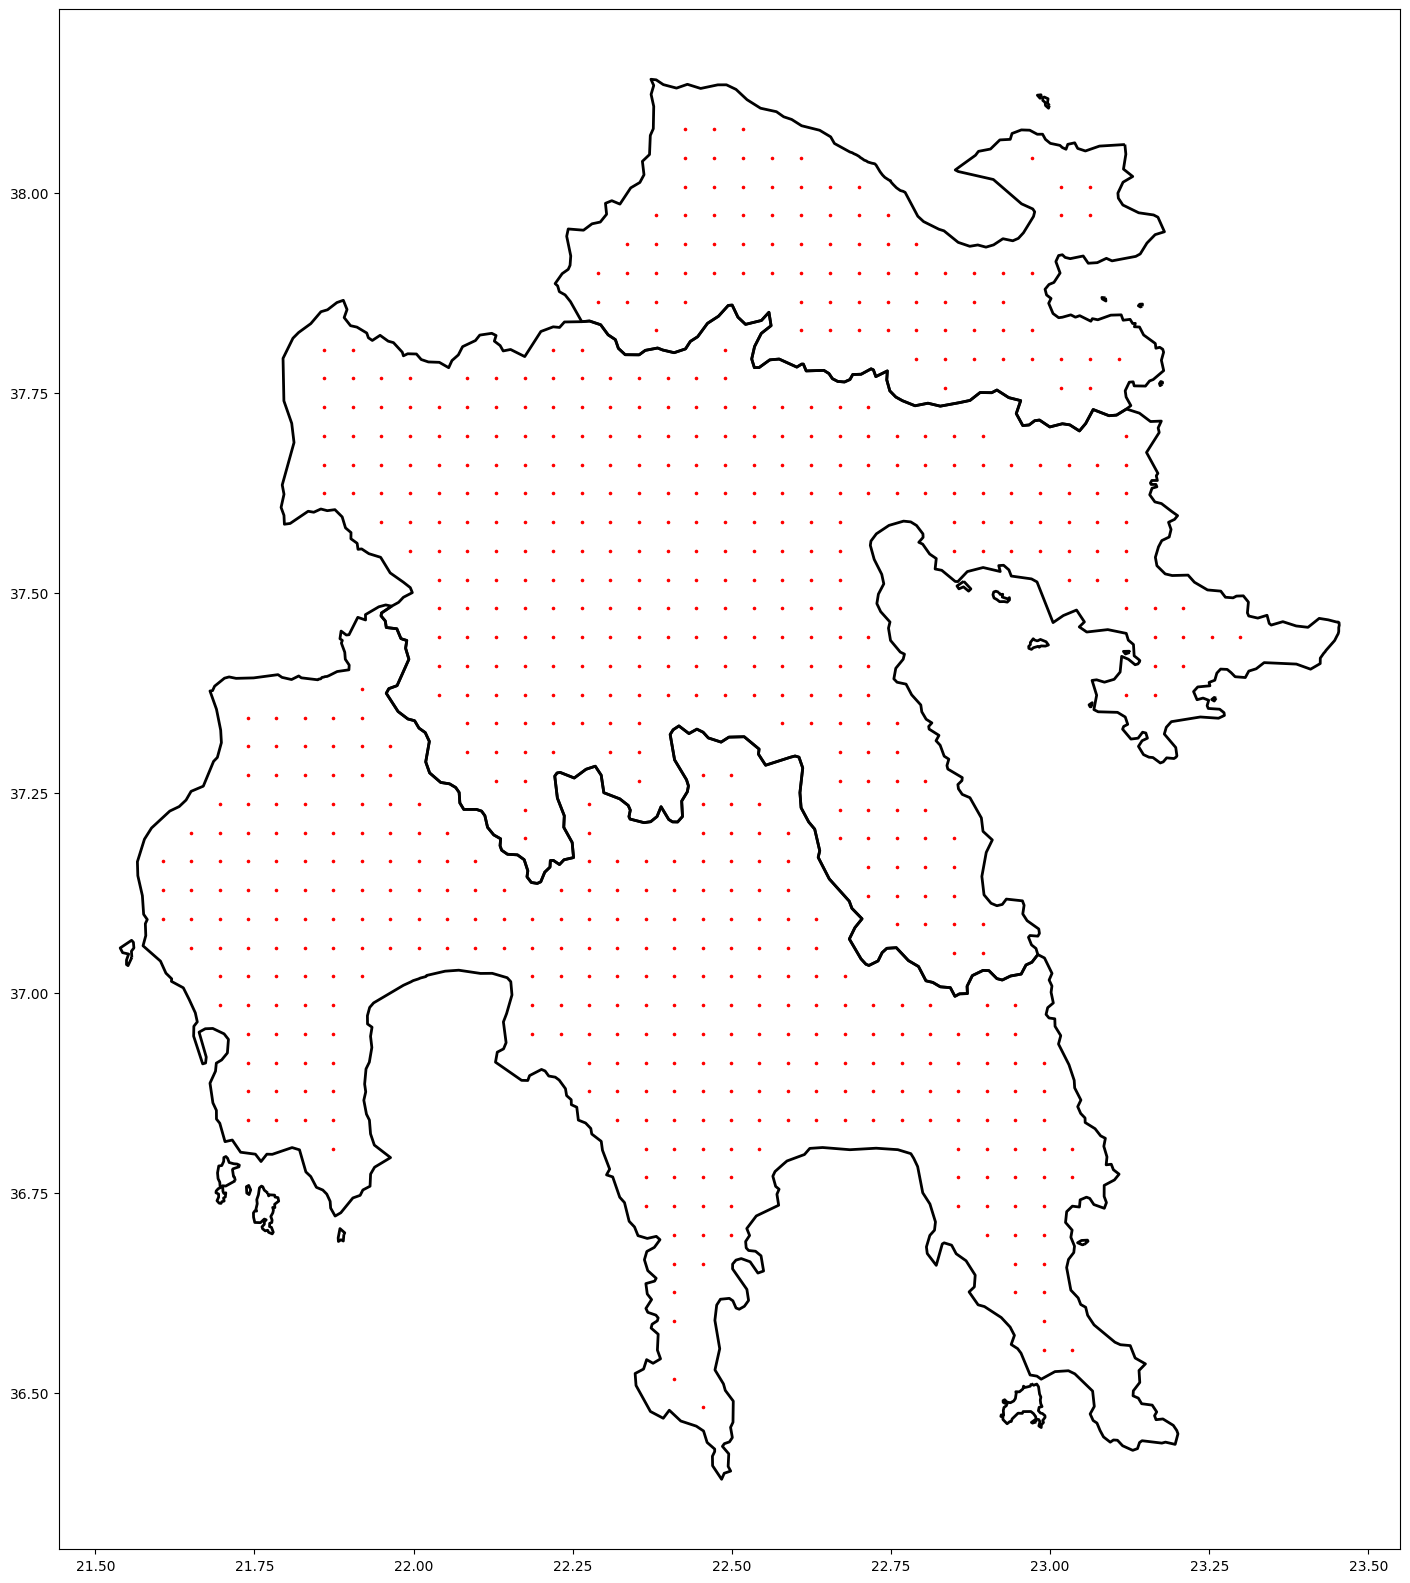

In [42]:
ax = nuts2_grid_points.plot(markersize=2.5, figsize=(20, 20), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [43]:
final_grid = pd.merge(nuts2_grid[['NUTS3_NAME', 'x', 'y']], nuts2_gdf[['NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], how='left', on=['NUTS3_NAME']) 
final_grid.sort_values(by=['NUTS3_NAME'], inplace = True)
final_grid = final_grid[['NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y']]

final_grid.reset_index(drop = True, inplace= True)

In [44]:
final_grid

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y
0,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.85941,37.62453
1,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.66925,37.26520
2,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.66925,37.22926
3,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.66925,37.19333
4,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.62425,37.73233
...,...,...,...,...,...,...
705,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",22.00785,37.09258
706,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",22.00785,37.05665
707,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",21.96321,37.30818
708,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",22.05249,37.05665


In [45]:
final_grid.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Grid_NUTS3.csv', encoding=enc, index = False)